In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from glob import glob
from os.path import join
benchmarks_dir="benchmarks_2025-09-11_09:49"
spmv_df = pd.concat(map(pd.read_csv, glob(join(benchmarks_dir, f"*spmv_multi_cube_128*.csv"))))
spmv_df["accelerator"] = "Ascend 910B4"

In [2]:
spmv_df.head()

,benchname,operator,dtype,nnz,time_us,accelerator
0,vsp_bcsstk30_500sep_10in_1Kout,spmv_multi_cube_128,fp16,4033156,437.63,Ascend 910B4
1,kron_g500-logn16,spmv_multi_cube_128,fp16,4912469,483.54,Ascend 910B4
2,enron,spmv_multi_cube_128,fp16,276143,286.23,Ascend 910B4
3,water_tank,spmv_multi_cube_128,fp16,2035281,416.66,Ascend 910B4
4,mip1,spmv_multi_cube_128,fp16,10352819,652.39,Ascend 910B4


In [3]:
eigen_mt_df = pd.concat(map(pd.read_csv, glob(join(benchmarks_dir, f"*eigen_spmv*32T*.csv"))))
eigen_mt_df["accelerator"] = "Eigen 32T"

In [4]:
mkl_mt_df = pd.concat(map(pd.read_csv, glob(join(benchmarks_dir, f"*mkl*32T*.csv"))))
mkl_mt_df["accelerator"] = "MKL 32T"

In [5]:
grand_df = pd.concat([spmv_df,mkl_mt_df,eigen_mt_df])
grand_df.head(100)

import math
benchnames = set()
for index, row in grand_df.iterrows():
    benchnames.add(row['benchname'])
nnz_dict = dict()
for index, row in grand_df.iterrows():
    if not math.isnan(row['nnz']):
        nnz_dict[row['benchname']] = int(row['nnz'])
for key, value in nnz_dict.items():
    grand_df.loc[grand_df.benchname == key, 'nnz'] = value
    new_bench_name = key.split('_')[0]
    if len(key.split('_')) > 1:
        new_bench_name = new_bench_name + f"_{key.split('_')[1]}"
    grand_df.loc[grand_df.benchname == key, 'benchname'] = new_bench_name
sorted_dict = sorted(nnz_dict, key=nnz_dict.get)
for i in sorted_dict:
    print(f"{i} & {i} & {nnz_dict[i]:.3E} & & \\\\")
for i, item in enumerate(sorted_dict):
    new_bench_name = item.split('_')[0]
    if len(item.split('_')) > 1:
        new_bench_name = new_bench_name + f"_{item.split('_')[1]}"
    sorted_dict[i] = new_bench_name
grand_df = grand_df.sort_values(by=['nnz','accelerator'])

considered_benchnames_suitesparse = [
# "vsp_bcsstk30_500sep_10in_1Kout",
# "kron_g500-logn16",
"enron", #
"water_tank", #
"mip1", #
# "gupta2",
# "bcircuit",
"TSOPF_FS", #
# "nasasrb",
# "qa8fm",
# "g7jac200",
# "pct20stif",
# "c-67b",
# "H2O",
# "Ga3As3H12",
"me2010", #
# "k1_san",
# "crankseg_2",
# "laminar_duct3D",
# "pdb1HYS",
# "pkustk04",
"crankseg_1", #
"struct3", #
# "c-70",
"Chebyshev4", #
# "GaAsH6",
"srb1", #
"cant", #
]
considered_benchnames_llm = [
"b-2_r-4",
"b-4_r-2",
"b-16_r-4",
"b-16_r-2",
"b-2_r-2",
"b-64_r-4",
"b-4_r-4",
"b-4_r-8",
"b-16_r-8",
# "b-4_r-6",
# "b-16_r-6",
"b-64_r-2",
"b-2_r-8",
"b-64_r-8",
# "b-64_r-6",
# "b-2_r-6",
]

enron & enron & 2.761E+05 & & \\
me2010 & me2010 & 3.355E+05 & & \\
bcircuit & bcircuit & 3.756E+05 & & \\
c-67b & c-67b & 5.319E+05 & & \\
k1_san & k1_san & 5.598E+05 & & \\
c-70 & c-70 & 6.590E+05 & & \\
g7jac200 & g7jac200 & 8.379E+05 & & \\
b-2_r-2_w-1_g-2_n-65536 & b-2_r-2_w-1_g-2_n-65536 & 9.174E+05 & & \\
struct3 & struct3 & 1.174E+06 & & \\
b-2_r-4_w-1_g-2_n-65536 & b-2_r-4_w-1_g-2_n-65536 & 1.180E+06 & & \\
b-2_r-6_w-1_g-2_n-65536 & b-2_r-6_w-1_g-2_n-65536 & 1.442E+06 & & \\
qa8fm & qa8fm & 1.661E+06 & & \\
b-2_r-8_w-1_g-2_n-65536 & b-2_r-8_w-1_g-2_n-65536 & 1.704E+06 & & \\
b-4_r-2_w-1_g-2_n-65536 & b-4_r-2_w-1_g-2_n-65536 & 1.835E+06 & & \\
water_tank & water_tank & 2.035E+06 & & \\
H2O & H2O & 2.217E+06 & & \\
b-4_r-4_w-1_g-2_n-65536 & b-4_r-4_w-1_g-2_n-65536 & 2.359E+06 & & \\
nasasrb & nasasrb & 2.677E+06 & & \\
pct20stif & pct20stif & 2.698E+06 & & \\
b-4_r-6_w-1_g-2_n-65536 & b-4_r-6_w-1_g-2_n-65536 & 2.883E+06 & & \\
srb1 & srb1 & 2.962E+06 & & \\
GaAsH6 & GaAsH6 & 3.3

['enron', 'me2010', 'struct3', 'water_tank', 'srb1', 'cant', 'Chebyshev4', 'TSOPF_FS', 'mip1', 'crankseg_1']
accelerator   benchname 
Ascend 910B4  Chebyshev4    1.000000
              TSOPF_FS      1.000000
              cant          1.000000
              crankseg_1    1.000000
              enron         1.000000
              me2010        1.000000
              mip1          1.000000
              srb1          1.000000
              struct3       1.000000
              water_tank    1.000000
Eigen 32T     Chebyshev4    2.383038
              TSOPF_FS      2.824571
              cant          0.422230
              crankseg_1    0.747740
              enron         0.337141
              me2010        0.306223
              mip1          0.969512
              srb1          0.348436
              struct3       0.297095
              water_tank    0.344406
MKL 32T       Chebyshev4    1.992371
              TSOPF_FS      1.333794
              cant          0.767705
              c

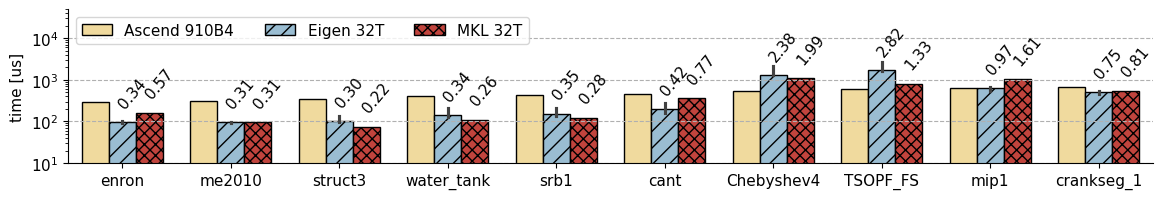

In [96]:

palette = [### Colorbrewer colors
"#fee090",
"#91bfdb",
# "#4575b4",
# "#fc8d59",
"#d73027",
# "#e0f3f8",
# "black"
]

plt.figure(figsize=(14,2))
hatches = ['', '//', 'xxx', '\\\\', '++','.']
tot_df_suitesparse = grand_df[grand_df["benchname"].isin(considered_benchnames_suitesparse)]
ax = sns.barplot(data=tot_df_suitesparse, x="benchname", y="time_us", hue="accelerator", edgecolor="black", palette=palette, estimator='median', width=0.75)
benchname_plot_order = []
for item in list(tot_df_suitesparse['benchname']):
    if item not in benchname_plot_order:
        benchname_plot_order.append(item)
print(benchname_plot_order)
import numpy as np
# print(tot_df_suitesparse.groupby(['benchname', 'accelerator'])['time_us'].apply(lambda x: np.mean(x.astype(np.double))))
medians = tot_df_suitesparse.groupby(['accelerator', 'benchname'])['time_us'].apply(lambda x: np.median(x.astype(np.double)))
speedup_vs_ascend_df = medians / medians['Ascend 910B4']
print(speedup_vs_ascend_df)
speedup_vs_ascend_list = []
for accel in ['Ascend 910B4', 'Eigen 32T', 'MKL 32T']:

    for item in benchname_plot_order:
        speedup_vs_ascend_list.append([accel, item, speedup_vs_ascend_df[accel][item]])
# print(medians)
print(speedup_vs_ascend_list)

for i, thisbar in enumerate(ax.patches):
    if i < 30:
        # Set a different hatch for each bar
        thisbar.set_hatch(hatches[int(i/10)])
    else:
        # these are for the legend
        thisbar.set_hatch(hatches[i%3])

for i, p in enumerate(ax.patches):
    if 10 <= i < 30:
        # print(i)
        # print(p)
        ax.annotate("%.2f" % speedup_vs_ascend_list[i][-1], xy=(p.get_x(), p.get_height() * 5),
            xytext=(5, 0), textcoords='offset points', ha="left", va="center",rotation=50)


num_accelerators = len(tot_df_suitesparse["accelerator"].unique()) / 3


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.rcParams.update({'font.size': 11})
# plt.legend(bbox_to_anchor=(0.5, 1.2), ncol=5)
plt.grid(linestyle='--', axis='y')
# plt.legend(loc='upper left', bbox_to_anchor =(0.0,1.2), ncol=3)
plt.legend(loc='upper left', ncol=3)
# plt.xticks(rotation=20, ha='center')
# plt.xlabel('matrix name')
plt.xlabel('')
plt.ylabel('time [us]')
plt.yscale('log')
plt.ylim(10,5e4)
plt.savefig("./spmv_comparison_suitesparse.pdf", bbox_inches='tight')


/tmp/ipykernel_1576757/1955510180.py:16: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  ax = sns.barplot(data=tot_df_llm, x="benchname", y="time_us", hue="accelerator", edgecolor="black", palette=palette, estimator='median', width=0.75)


['b-2_r-2', 'b-2_r-4', 'b-2_r-8', 'b-4_r-2', 'b-4_r-4', 'b-4_r-8', 'b-16_r-2', 'b-16_r-4', 'b-16_r-8', 'b-64_r-2', 'b-64_r-4', 'b-64_r-8']
accelerator   benchname
Ascend 910B4  b-16_r-2     1.000000
              b-16_r-4     1.000000
              b-16_r-8     1.000000
              b-2_r-2      1.000000
              b-2_r-4      1.000000
              b-2_r-8      1.000000
              b-4_r-2      1.000000
              b-4_r-4      1.000000
              b-4_r-8      1.000000
              b-64_r-2     1.000000
              b-64_r-4     1.000000
              b-64_r-8     1.000000
Eigen 32T     b-16_r-2     3.317143
              b-16_r-4     3.867509
              b-16_r-8     2.670539
              b-2_r-2      0.797144
              b-2_r-4      1.168480
              b-2_r-8      0.864557
              b-4_r-2      2.687271
              b-4_r-4      1.332718
              b-4_r-8      1.108226
              b-64_r-2     6.391863
              b-64_r-4     4.967327
         

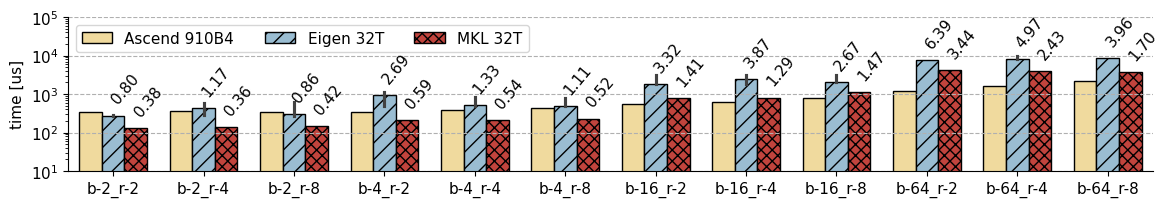

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns

palette = [### Colorbrewer colors
"#fee090",
"#91bfdb",
# "#4575b4",
# "#fc8d59",
"#d73027",
"#e0f3f8",
"black"]

plt.figure(figsize=(14,2))
tot_df_llm = grand_df[grand_df["benchname"].isin(considered_benchnames_llm)]
hatches = ['', '//', 'xxx', '\\\\', '++','.']
ax = sns.barplot(data=tot_df_llm, x="benchname", y="time_us", hue="accelerator", edgecolor="black", palette=palette, estimator='median', width=0.75)
benchname_plot_order = []
for item in list(tot_df_llm['benchname']):
    if item not in benchname_plot_order:
        benchname_plot_order.append(item)
print(benchname_plot_order)
import numpy as np
medians = tot_df_llm.groupby(['accelerator', 'benchname'])['time_us'].apply(lambda x: np.median(x.astype(np.double)))
speedup_vs_ascend_df = medians / medians['Ascend 910B4']
print(speedup_vs_ascend_df)
speedup_vs_ascend_list = []
for accel in ['Ascend 910B4', 'Eigen 32T', 'MKL 32T']:

    for item in benchname_plot_order:
        speedup_vs_ascend_list.append([accel, item, speedup_vs_ascend_df[accel][item]])
print(speedup_vs_ascend_list)


for i, thisbar in enumerate(ax.patches):
    if i < 36:
        # Set a different hatch for each bar
        thisbar.set_hatch(hatches[int(i/12)])
    else:
        # these are for the legend
        thisbar.set_hatch(hatches[i%3])

for i, p in enumerate(ax.patches):
    if 12 <= i < 36:
        # print(i)
        # print(p)
        ax.annotate("%.2f" % speedup_vs_ascend_list[i][-1], xy=(p.get_x(), p.get_height() * 5),
            xytext=(5, 0), textcoords='offset points', ha="left", va="center",rotation=50)

num_accelerators = len(tot_df_llm["accelerator"].unique()) / 3

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.rcParams.update({'font.size': 11})
# plt.legend(bbox_to_anchor=(0.5, 1.2), ncol=5)
plt.grid(linestyle='--', axis='y')
# plt.legend(loc='upper left', bbox_to_anchor =(0.0,1.2), ncol=3)
plt.legend(loc='upper left', ncol=3)
# plt.xticks(rotation=20, ha='center')
# plt.xlabel('matrix name')
plt.xlabel('')
plt.ylabel('time [us]')
plt.yscale('log')
plt.ylim(10,1e5)
plt.savefig("spmv_comparison_llm.pdf", bbox_inches='tight')
# plt.close()

/tmp/ipykernel_739238/3416357372.py:20: UserWarning: The palette list has more values (7) than needed (5), which may not be intended.
  sns.barplot(data=dfs[0], x="benchname", y="time_us", hue="accelerator", edgecolor="black", palette=palette, estimator='median', width=0.75, ax=axes[0])
/tmp/ipykernel_739238/3416357372.py:21: UserWarning: The palette list has more values (7) than needed (5), which may not be intended.
  sns.barplot(data=dfs[1], x="benchname", y="time_us", hue="accelerator", edgecolor="black", palette=palette, estimator='median', width=0.75, ax=axes[1])
/tmp/ipykernel_739238/3416357372.py:22: UserWarning: The palette list has more values (7) than needed (5), which may not be intended.
  sns.barplot(data=dfs[2], x="benchname", y="time_us", hue="accelerator", edgecolor="black", palette=palette, estimator='median', width=0.75, ax=axes[2])
/tmp/ipykernel_739238/3416357372.py:23: UserWarning: The palette list has more values (7) than needed (5), which may not be intended.
  

in 35
in 36
in 37
in 38
in 39
in 35
in 36
in 37
in 38
in 39
in 35
in 36
in 37
in 38
in 39
in 35
in 36
in 37
in 38
in 39


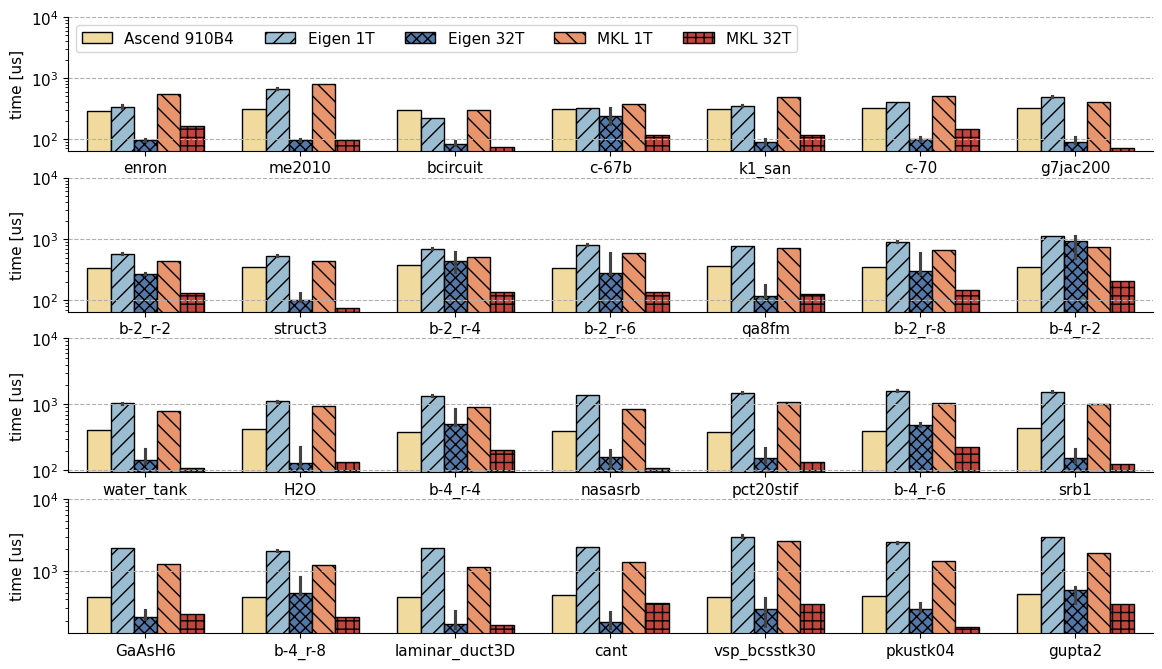

In [107]:
import matplotlib.pyplot as plt
import seaborn as sns

palette = [### Colorbrewer colors
"#fee090",
"#91bfdb",
"#4575b4",
"#fc8d59",
"#d73027",
"#e0f3f8",
"black"]

fig, axes = plt.subplots(4,1,figsize=(14,8))
dfs = []
dfs.append(grand_df[grand_df.benchname.isin(sorted_dict[0:7])])
dfs.append(grand_df[grand_df.benchname.isin(sorted_dict[7:14])])
dfs.append(grand_df[grand_df.benchname.isin(sorted_dict[14:21])])
dfs.append(grand_df[grand_df.benchname.isin(sorted_dict[21:28])])

sns.barplot(data=dfs[0], x="benchname", y="time_us", hue="accelerator", edgecolor="black", palette=palette, estimator='median', width=0.75, ax=axes[0])
sns.barplot(data=dfs[1], x="benchname", y="time_us", hue="accelerator", edgecolor="black", palette=palette, estimator='median', width=0.75, ax=axes[1])
sns.barplot(data=dfs[2], x="benchname", y="time_us", hue="accelerator", edgecolor="black", palette=palette, estimator='median', width=0.75, ax=axes[2])
sns.barplot(data=dfs[3], x="benchname", y="time_us", hue="accelerator", edgecolor="black", palette=palette, estimator='median', width=0.75, ax=axes[3])

num_accelerators = len(grand_df["accelerator"].unique()) / 3

hatches = ['', '//', 'xxx', '\\\\', '++','.']
for i, ax in enumerate(axes):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # ax = sns.barplot(data=dfs[i], x="benchname", y="time_us", hue="accelerator", edgecolor="black", palette=palette, estimator='median', width=0.75)

plt.rcParams.update({'font.size': 11})
# plt.legend(bbox_to_anchor=(0.5, 1.2), ncol=5)
plt.grid(linestyle='--', axis='y')
# plt.legend(loc='upper left', bbox_to_anchor =(0.0,1.2), ncol=3)
for ax in axes:
    ax.get_legend().remove()
    # ax.set_xticks(rotation=20, ha='center')
    ax.set_xlabel('')
    ax.set_ylabel('time [us]')
    ax.set_yscale('log')
    ax.set_ylim(0,1e4)
    ax.grid(linestyle='--', axis='y')
for ax in axes:
    for i, thisbar in enumerate(ax.patches):
        # print(i)
        if i < 35:
            # Set a different hatch for each bar
            thisbar.set_hatch(hatches[int(i/7)])
        else:
            print(f'in {i}')
            # these are for the legend
            thisbar.set_hatch(hatches[i%5])
axes[0].legend(loc='upper left', ncol=5)
# plt.xlabel('matrix name')
plt.savefig("spmv_comparison_full_28_matrices.pdf", bbox_inches='tight')